# Author

Name: Vanshika Rathore

Project: Ecommerce Customers Spending Prediction using Linear Regression

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

# Ecommerce Customers Spending Prediction using Linear Regression

## Project Overview

This project predicts the yearly amount spent by customers using their online shopping behavior.

The objective is to understand which customer factors influence spending the most and build a machine learning model capable of predicting future customer spending.

# Problem Statement

An e-commerce company wants to predict how much a customer will spend yearly based on customer behavior metrics.

The goal is to identify important factors influencing spending and help the company make data-driven business decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import sklearn

print("Everything Working!")
print(sklearn.__version__)

Everything Working!
1.5.1


In [3]:
customers = pd.read_csv('../data/Ecommerce Customers')

# Dataset Description

The dataset contains information about 500 customers.

Features:
- Avg. Session Length
- Time on App
- Time on Website
- Length of Membership

Target Variable:
- Yearly Amount Spent

Additional columns such as Email, Address, and Avatar are not used for prediction.

In [4]:
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [6]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


# Exploratory Data Analysis (EDA)

EDA helps us understand relationships between variables using visualizations.

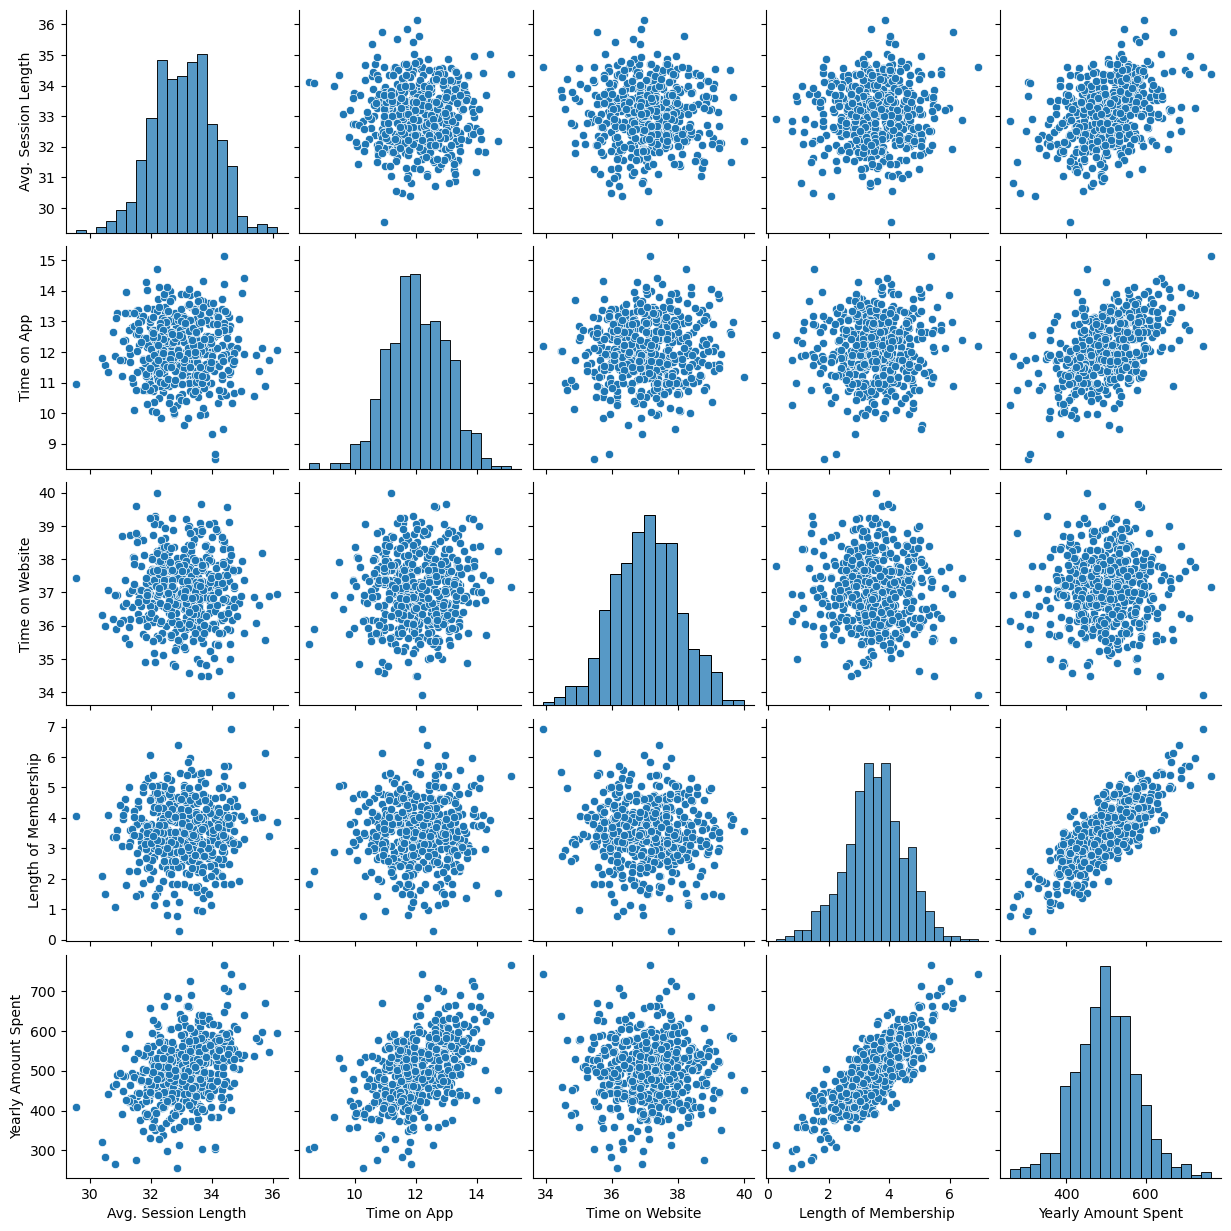

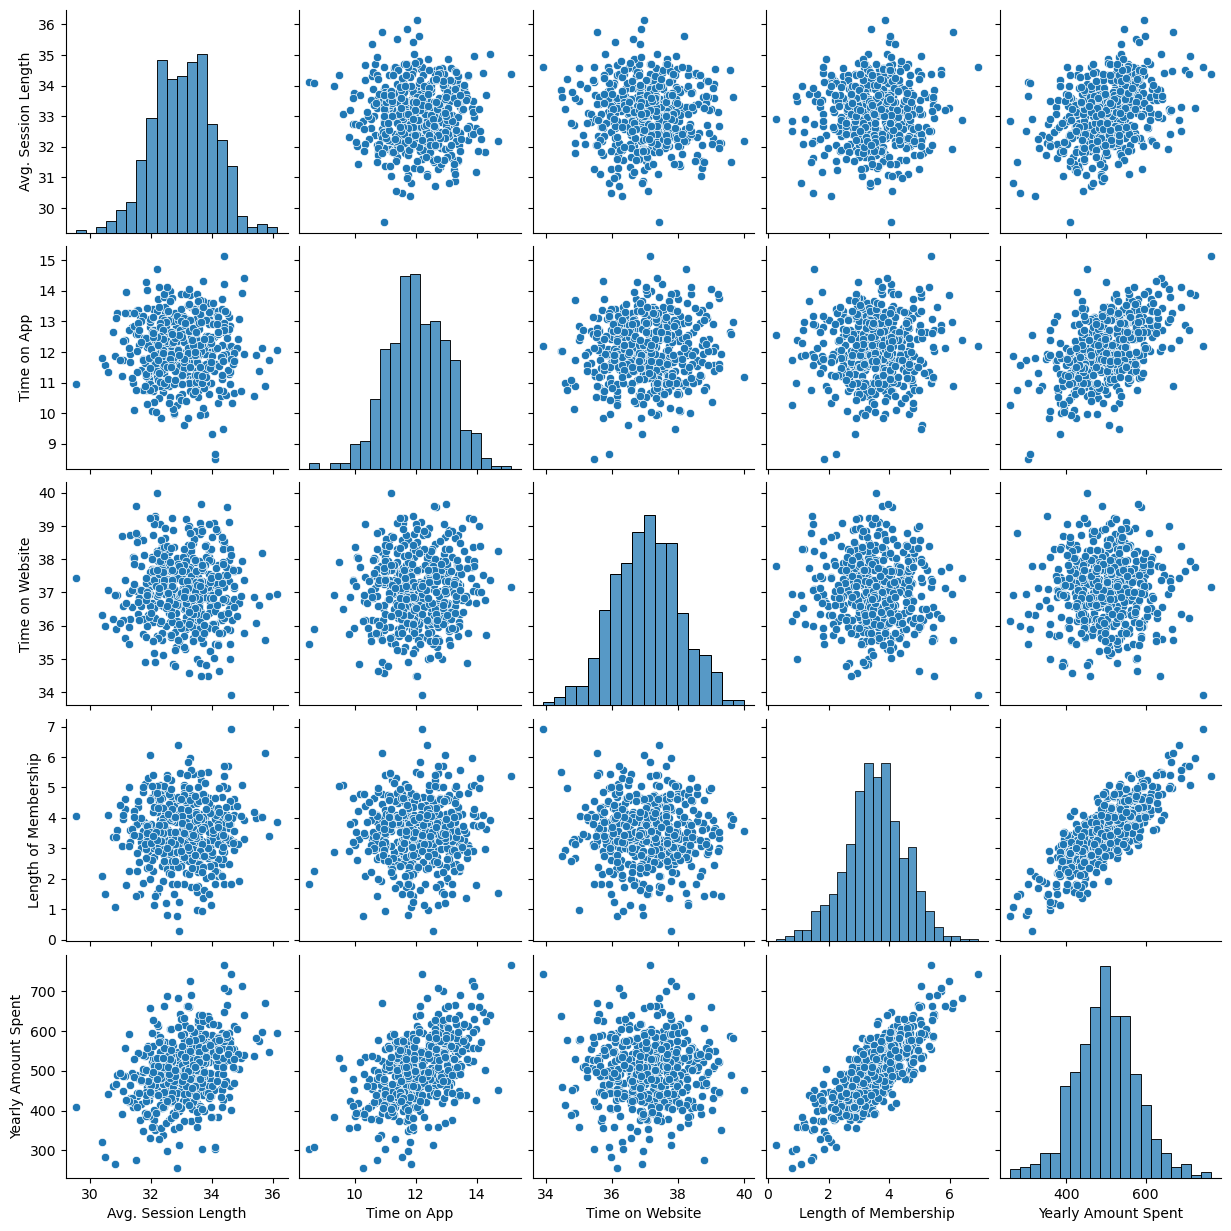

In [8]:
sns.pairplot(customers)
plt.show()

# Feature Selection

Selecting input features and target variable.

In [9]:
X = customers[['Avg. Session Length',
               'Time on App',
               'Time on Website',
               'Length of Membership']]

y = customers['Yearly Amount Spent']

# Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=101
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(350, 4)
(150, 4)


# Model Training

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lm = LinearRegression()

In [15]:
lm.fit(X_train, y_train)

LinearRegression()

In [16]:
print("Model Trained Successfully!")

Model Trained Successfully!


# Model Coefficients

In [17]:
coeff_df = pd.DataFrame(
    lm.coef_,
    X.columns,
    columns=['Coefficient']
)

coeff_df

,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


# Prediction

In [18]:
predictions = lm.predict(X_test)

In [19]:
predictions[:5]

array([456.44186104, 402.72005312, 409.2531539 , 591.4310343 ,
       590.01437275])

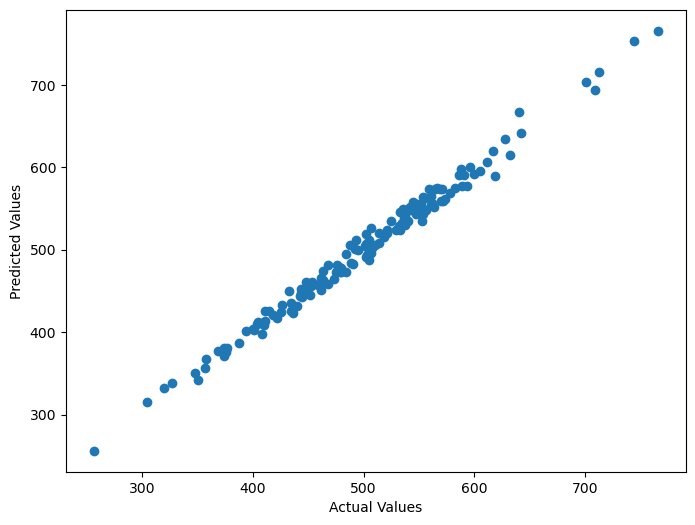

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

# Model Evaluation

In [21]:
from sklearn import metrics

In [22]:
print("MAE :", metrics.mean_absolute_error(y_test, predictions))
print("MSE :", metrics.mean_squared_error(y_test, predictions))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE : 7.228148653430815
MSE : 79.81305165097409
RMSE : 8.933815066978614


# Conclusion

Length of Membership is the strongest predictor of customer spending.

Time on App has a significant effect on spending.

The company should focus on customer retention and improving the mobile app experience.

In [23]:
coeff_df

,Coefficient
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


In [24]:
predictions = lm.predict(X_test)

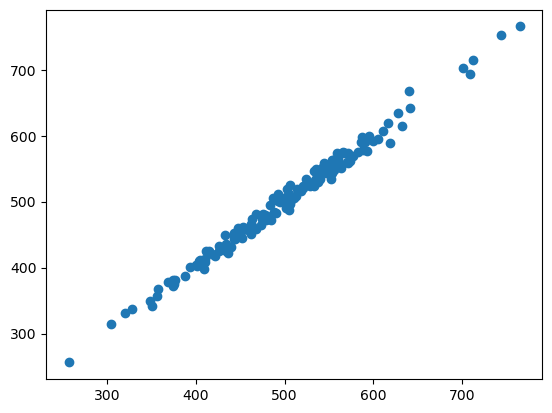

In [29]:
plt.scatter(y_test, predictions)
plt.show()

In [26]:
print("MAE :", metrics.mean_absolute_error(y_test, predictions))
print("MSE :", metrics.mean_squared_error(y_test, predictions))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE : 7.228148653430815
MSE : 79.81305165097409
RMSE : 8.933815066978614


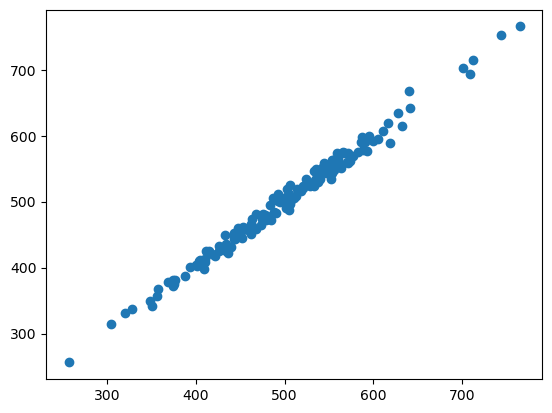

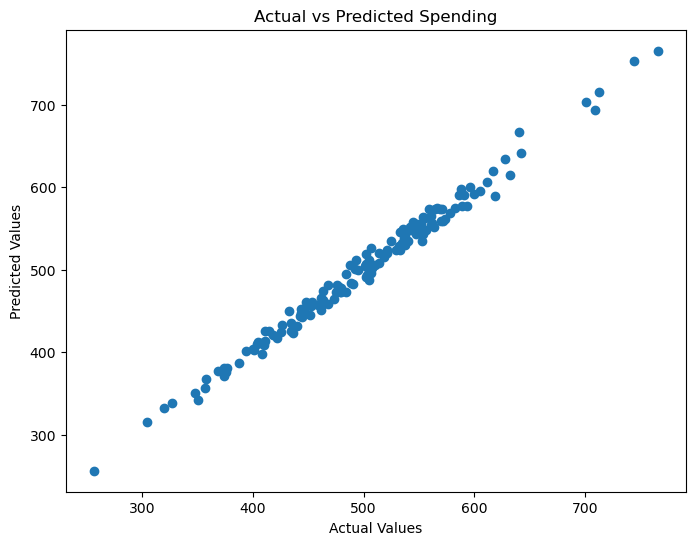

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Spending")

plt.show()

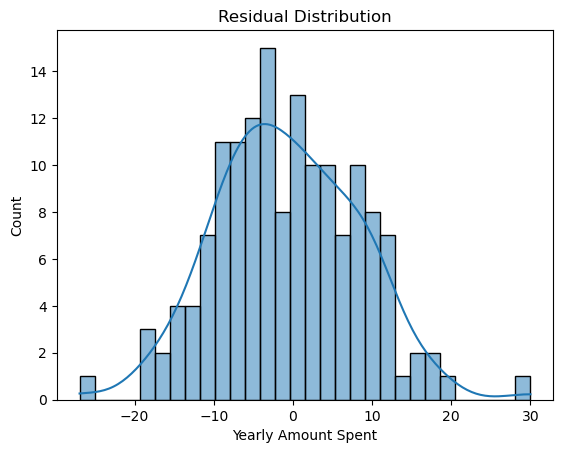

In [28]:
sns.histplot((y_test - predictions), bins=30, kde=True)
plt.title("Residual Distribution")
plt.show()